# Simülasyon Veri Kalitesi Notebook'u

Faz 1 · A1.5 — Kişi A

Bu notebook üç şeyi doğrular:
1. Katalog + simülasyon çıktısının **Parquet'e yazılıp geri okunabildiğini**
2. Temel istatistiklerin ve grafiklerin **beklenen davranışı gösterdiğini**
   (Pareto ciro dağılımı, talep sezonsallığı, mutabakat)
3. **Patolojiler açıkken** verinin gözle görülür şekilde bozulduğunu, kapalıyken
   sağlıklı kaldığını (A1.4'ün "bitti sayılır" kriteri)

Kişi B bu notebook'a bakıp verinin mantıklı olduğunu onaylayacak (SP1 buluşma noktası).


In [1]:
import sys
from pathlib import Path

for _aday in [Path.cwd(), *Path.cwd().parents]:
    if (_aday / "pyproject.toml").exists():
        sys.path.insert(0, str(_aday))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulator.company import yapi_malzemesi_toptancisi
from simulator.pathologies import PatolojiKonfigurasyonu
from simulator.run import simulasyon_calistir, sonucu_diske_yaz

plt.rcParams["figure.figsize"] = (12, 5)
profile = yapi_malzemesi_toptancisi()


## 1. Simülasyonu çalıştır ve Parquet'e yaz

İki koşum: **sağlıklı** (seed 42) ve **patolojili** (seed 43, tüm patolojiler açık).

In [2]:
sonuc_saglikli = simulasyon_calistir(profile=profile, seed=42, yil_sayisi=3)
dizin_saglikli = sonucu_diske_yaz(sonuc_saglikli, seed=42)
print("Sağlıklı veri yazıldı:", dizin_saglikli)


Sağlıklı veri yazıldı: data\sim\42


In [3]:
patoloji_konfig = PatolojiKonfigurasyonu(
    tedarikci_gecikmesi_aktif=True,
    talep_patlamasi_aktif=True,
    olu_stok_aktif=True,
    fiyat_zammi_aktif=True,
    sezon_sonu_fazlasi_aktif=True,
    sayim_farki_aktif=True,
)
sonuc_patolojili = simulasyon_calistir(
    profile=profile, seed=43, yil_sayisi=3, patoloji_konfig=patoloji_konfig
)
dizin_patolojili = sonucu_diske_yaz(sonuc_patolojili, seed=43)
print("Patolojili veri yazıldı:", dizin_patolojili)


Patolojili veri yazıldı: data\sim\43


### Geri okuma testi

Diskten okuyup bellekteki sonuçla aynı olduğunu doğrula.

In [4]:
geri_okunan_sku = pd.read_parquet(dizin_saglikli / "sku.parquet")
assert geri_okunan_sku.equals(sonuc_saglikli["sku"]), "Parquet round-trip verisi farklı!"
print("Parquet round-trip OK —", len(geri_okunan_sku), "SKU satırı.")


Parquet round-trip OK — 2000 SKU satırı.


## 2. Katalog temel istatistikleri

In [5]:
sku_df = sonuc_saglikli["sku"]
print("SKU sayısı:", len(sku_df))
print("Tedarikçi sayısı:", len(sonuc_saglikli["tedarikci"]))
print("Müşteri sayısı:", len(sonuc_saglikli["musteri"]))
print()
print("Kategori dağılımı:")
print(sku_df["kategori"].value_counts())


SKU sayısı: 2000
Tedarikçi sayısı: 60
Müşteri sayısı: 800

Kategori dağılımı:
kategori
demir        264
tugla        264
izolasyon    255
alci         255
boya         249
cimento      247
hirdavat     237
seramik      229
Name: count, dtype: int64


### Pareto / Lorenz kontrolü — üst %20 SKU cironun ~%80'ini taşımalı

Üst %20 SKU -> ciro payı: 0.800 (hedef: ~0.80)


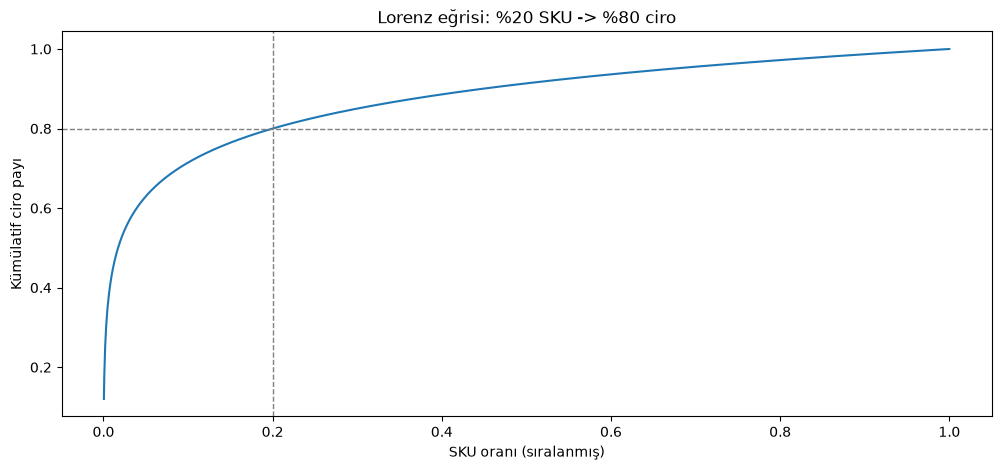

In [6]:
siralanmis_pay = sku_df["yillik_ciro_payi"].sort_values(ascending=False).to_numpy()
kumulatif = np.cumsum(siralanmis_pay)
sku_orani = np.arange(1, len(kumulatif) + 1) / len(kumulatif)

top20_pay = kumulatif[int(len(kumulatif) * 0.20) - 1]
print(f"Üst %20 SKU -> ciro payı: {top20_pay:.3f} (hedef: ~0.80)")
assert abs(top20_pay - 0.80) < 0.02, "Pareto oranı hedeften çok sapmış!"

fig, ax = plt.subplots()
ax.plot(sku_orani, kumulatif)
ax.axvline(0.2, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.8, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("SKU oranı (sıralanmış)")
ax.set_ylabel("Kümülatif ciro payı")
ax.set_title("Lorenz eğrisi: %20 SKU -> %80 ciro")
plt.show()


## 3. Talep grafiği — trend + yıllık sezon + haftalık desen

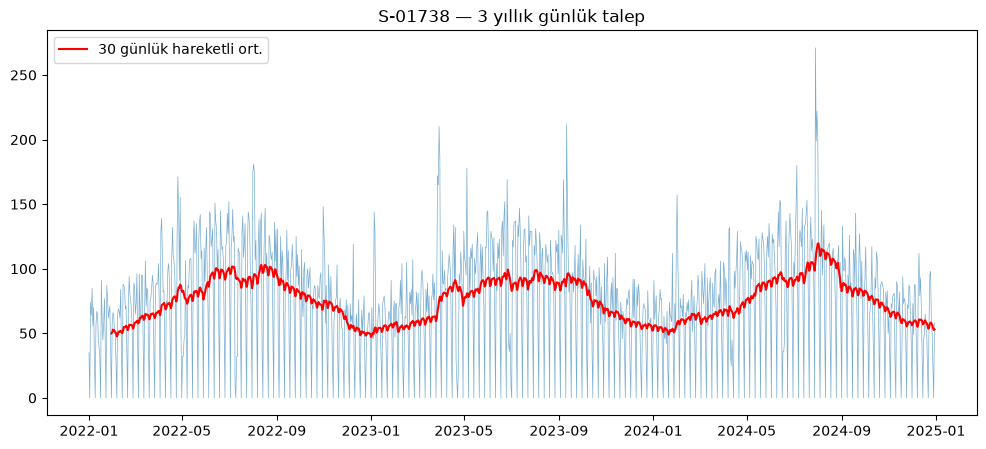

In [7]:
ornek_sku_id = sku_df.sort_values("yillik_ciro_payi", ascending=False).iloc[0]["sku_id"]
talep_ornek = (
    sonuc_saglikli["talep"][sonuc_saglikli["talep"]["sku_id"] == ornek_sku_id]
    .set_index("tarih")["talep_miktari"]
)

fig, ax = plt.subplots()
ax.plot(talep_ornek.index, talep_ornek.values, linewidth=0.5, alpha=0.6)
ax.plot(
    talep_ornek.index,
    talep_ornek.rolling(30).mean(),
    color="red",
    linewidth=1.5,
    label="30 günlük hareketli ort.",
)
ax.set_title(f"{ornek_sku_id} — 3 yıllık günlük talep")
ax.legend()
plt.show()


## 4. Mutabakat kontrolü — sağlıklı vs patolojili

In [8]:
for etiket, sonuc in [("sağlıklı", sonuc_saglikli), ("patolojili", sonuc_patolojili)]:
    max_fark = sonuc["mutabakat"]["fark"].abs().max()
    negatif_stok = (sonuc["envanter_gunluk"]["eldeki_stok"] < 0).sum()
    print(f"[{etiket}] mutabakat max |fark|: {max_fark:.6f} | negatif stok satırı: {negatif_stok}")
    assert max_fark < 1e-6, f"{etiket} veri setinde mutabakat bozuk!"
    assert negatif_stok == 0, f"{etiket} veri setinde negatif stok var!"
print("Mutabakat ve negatif-stok kontrolleri geçti.")


[sağlıklı] mutabakat max |fark|: 0.000000 | negatif stok satırı: 0
[patolojili] mutabakat max |fark|: 0.000000 | negatif stok satırı: 0
Mutabakat ve negatif-stok kontrolleri geçti.


## 5. Karşılanamayan talep — sağlıklı vs patolojili karşılaştırma

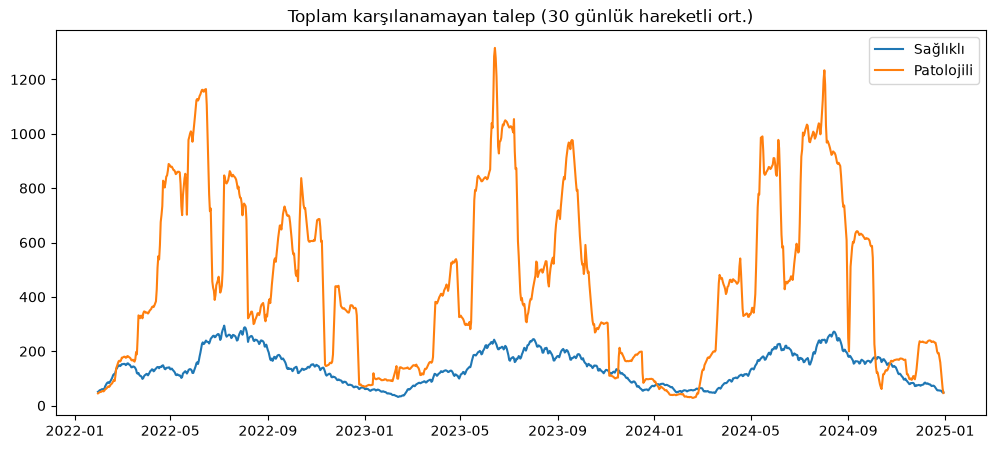

Toplam karşılanamayan (sağlıklı): 150693
Toplam karşılanamayan (patolojili): 482949


In [9]:
def gunluk_karsilanamayan(sonuc):
    tarih_araligi = pd.date_range(
        sonuc["envanter_gunluk"]["tarih"].min(), sonuc["envanter_gunluk"]["tarih"].max()
    )
    return (
        sonuc["karsilanamayan_talep"]
        .groupby("tarih")["karsilanamayan_miktar"]
        .sum()
        .reindex(tarih_araligi, fill_value=0)
    )


karsilanamayan_saglikli = gunluk_karsilanamayan(sonuc_saglikli)
karsilanamayan_patolojili = gunluk_karsilanamayan(sonuc_patolojili)

fig, ax = plt.subplots()
ax.plot(
    karsilanamayan_saglikli.index, karsilanamayan_saglikli.rolling(30).mean(), label="Sağlıklı"
)
ax.plot(
    karsilanamayan_patolojili.index,
    karsilanamayan_patolojili.rolling(30).mean(),
    label="Patolojili",
)
ax.set_title("Toplam karşılanamayan talep (30 günlük hareketli ort.)")
ax.legend()
plt.show()

print("Toplam karşılanamayan (sağlıklı):", int(karsilanamayan_saglikli.sum()))
print("Toplam karşılanamayan (patolojili):", int(karsilanamayan_patolojili.sum()))


## 6. Patoloji zaman çizgisi

Her enjeksiyonun ne zaman olduğu — Faz 5'in "modelimiz bu olayı yakaladı mı?" ölçümünün dayanağı.

Toplam patoloji olayı: 328
tur
TEDARIKCI_GECIKMESI    186
TALEP_PATLAMASI         60
OLU_STOK                40
SEZON_SONU_FAZLASI      24
SAYIM_FARKI             12
FIYAT_ZAMMI              6
Name: count, dtype: int64



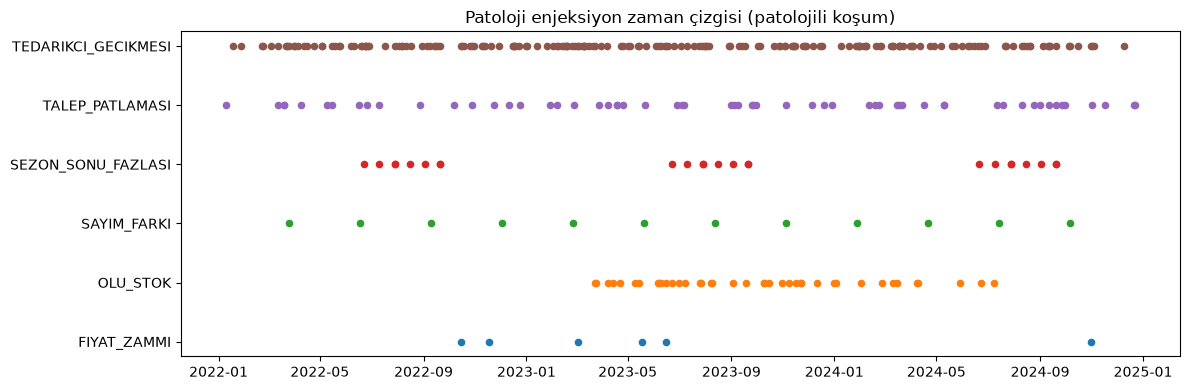

In [10]:
olaylar = sonuc_patolojili["patoloji_olaylari"]
print("Toplam patoloji olayı:", len(olaylar))
print(olaylar["tur"].value_counts())
print()

turler = sorted(olaylar["tur"].unique())
fig, ax = plt.subplots(figsize=(12, 4))
for i, tur in enumerate(turler):
    alt_kume = olaylar[olaylar["tur"] == tur]
    ax.scatter(alt_kume["tarih"], [i] * len(alt_kume), label=tur, s=20)
ax.set_yticks(range(len(turler)))
ax.set_yticklabels(turler)
ax.set_title("Patoloji enjeksiyon zaman çizgisi (patolojili koşum)")
plt.tight_layout()
plt.show()


## 7. Sağlıklı vs patolojili — özet karşılaştırma

Patolojiler kapalıyken veri sağlıklı, açıkken belirgin sorunlu olmalı (A1.4 bitti-sayılır kriteri).

In [11]:
ozet = pd.DataFrame(
    {
        "sağlıklı": {
            "toplam_talep": int(sonuc_saglikli["talep"]["talep_miktari"].sum()),
            "toplam_karsilanamayan": int(
                sonuc_saglikli["karsilanamayan_talep"]["karsilanamayan_miktar"].sum()
            ),
            "siparis_sayisi": len(sonuc_saglikli["siparisler"]),
            "patoloji_olayi": len(sonuc_saglikli["patoloji_olaylari"]),
        },
        "patolojili": {
            "toplam_talep": int(sonuc_patolojili["talep"]["talep_miktari"].sum()),
            "toplam_karsilanamayan": int(
                sonuc_patolojili["karsilanamayan_talep"]["karsilanamayan_miktar"].sum()
            ),
            "siparis_sayisi": len(sonuc_patolojili["siparisler"]),
            "patoloji_olayi": len(sonuc_patolojili["patoloji_olaylari"]),
        },
    }
)
ozet


,sağlıklı,patolojili
toplam_talep,2199485,5811104
toplam_karsilanamayan,150693,482949
siparis_sayisi,11867,11209
patoloji_olayi,0,328


## Sonuç

- Parquet round-trip doğrulandı.
- Pareto ilkesi (üst %20 SKU → ~%80 ciro) doğrulandı.
- Talep grafiğinde trend + yıllık sezon + haftalık desen görülüyor.
- Mutabakat (`baslangıç + teslim_alınan + sayım_düzeltmesi − sevkiyat = son_stok`) hem
  sağlıklı hem patolojili veri setinde tam tutuyor.
- Negatif stok satırı yok.
- Patolojiler kapalıyken veri sağlıklı, açıkken karşılanamayan talep belirgin şekilde
  artıyor ve her enjeksiyon `patoloji_olaylari` tablosunda zaman damgalı olarak kayıtlı.

**Kişi B onayı bekleniyor (SP1 buluşma noktası).**
